In [29]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.integrate import odeint
import lmfit
from lmfit import Model
import string

plt.style.use("seaborn-v0_8-white")
matplotlib.rcParams["axes.labelsize"] = 20
matplotlib.rcParams["axes.titlesize"] = 24
matplotlib.rcParams["xtick.labelsize"] = 15
matplotlib.rcParams["ytick.labelsize"] = 15
matplotlib.rcParams["xtick.major.size"] = 10
matplotlib.rcParams["ytick.major.size"] = 10
matplotlib.rcParams["xtick.minor.size"] = 5
matplotlib.rcParams["ytick.minor.size"] = 5

Path("figures").mkdir(exist_ok=True)
AGG_PANELS = []


# Aggregation vs biphasic simulation code

## Replicate handling

In [30]:
# Collapse replicates
def collapse_replicates(t, y, sem=None):
    """ Collapse replicate measurements at identical time points """
    t = np.asarray(t)
    y = np.asarray(y)
    t_u = np.unique(t)
    y_mean = np.zeros_like(t_u, dtype=float)
    sem_u  = None if sem is None else np.zeros_like(t_u, dtype=float)
    for i, ti in enumerate(t_u):
        mask = t == ti
        y_mean[i] = np.mean(y[mask])
        if sem is not None:
            sem_i = sem[mask]
            sem_u[i] = np.sqrt(np.sum(sem_i**2)) / np.sum(mask)
    return t_u, y_mean, sem_u

## Exponential and biphasic models

In [31]:
# Basic models (exp, bi)
def make_log10_exp(V0):
    def log10_exp(t, k):
        W = V0 * np.exp(-k * t)
        W = np.clip(W, 1e-12, np.inf)
        return np.log10(W)
    return log10_exp

def make_log10_bi(V0):
    def log10_bi(t, p, k1, k2):
        p_eff  = np.clip(p, 1e-12, 1 - 1e-12)
        k1_eff = max(k1, 0.0)
        k2_eff = max(k2, 0.0)
        W = V0 * (p_eff*np.exp(-k1_eff*t) + (1-p_eff)*np.exp(-k2_eff*t))
        W = np.clip(W, 1e-12, np.inf)
        return np.log10(W)
    return log10_bi

def exponential_linear(t, V0, k):
    return V0 * np.exp(-k * t)

def biphasic_linear(t, V0, p, k1, k2):
    return V0 * (p*np.exp(-k1*t) + (1-p)*np.exp(-k2*t))

## Aggregation ODE models

In [32]:
# Aggregation ODEs
def agg_ode_genome(Y, t, f, delta, d):
    Vs, Va = Y
    dVs = -2.0*f*Vs**2 - d*Vs + 2.0*delta*Va
    dVa =  2.0*f*Vs**2 - 2.0*delta*Va
    return [dVs, dVa]

def agg_ode_pfu(Y, t, f, delta, d):
    Vs, Va = Y
    dVs = -2.0*f*Vs**2 - d*Vs + 2.0*delta*Va
    dVa =  f*Vs**2 - delta*Va
    return [dVs, dVa]

# ODE caller
def agg_linear(t, V0, f, delta, d, p0, mode="density"):
    t = np.asarray(t, float)
    Vs0 = p0 * V0
    Va0 = (1.0 - p0) * V0
    Y0  = [Vs0, Va0]
    if mode == "density":
        sol = odeint(agg_ode_genome, Y0, t, args=(f, delta, d))
    elif mode == "PFU":
        sol = odeint(agg_ode_pfu, Y0, t, args=(f, delta, d))
    else:
        raise ValueError("mode must be 'density' or 'PFU'")
    Vs, Va = sol.T
    return Vs + Va

## Maps aggregation modles into log10-space

In [33]:
# Aggregation log10 model(s)
def make_log10_agg_mapped(V0, p_bi, k1, k2, mode="density"):
    """Returns a log10 aggregation model for lmfit, mode="density": fit parameters are (p0, f), delta fixed at k2/2, 
    d is computed as d = S_bi / p0, mode="PFU": fit parameters are (p0, f, d), delta fixed at k2"""
    S_bi = p_bi * k1 + (1.0 - p_bi) * k2
    if mode == "density":
        delta_fixed = k2 / 2.0
        def log10_agg(t, p0, f):
            p0_eff = np.clip(p0, 1e-12, 1.0)
            f_eff  = max(f, 0.0)
            d_eff  = S_bi / p0_eff
            W = agg_linear(t, V0, f_eff, delta_fixed, d_eff, p0_eff, mode="density")
            W = np.clip(W, 1e-12, np.inf)
            return np.log10(W)
        return log10_agg
    elif mode == "PFU":
        delta_fixed = k2
        def log10_agg(t, p0, f, d):
            p0_eff = np.clip(p0, 1e-12, 1.0)
            f_eff  = max(f, 0.0)
            d_eff  = max(d, 0.0)
            W = agg_linear(t, V0, f_eff, delta_fixed, d_eff, p0_eff, mode="PFU")
            W = np.clip(W, 1e-12, np.inf)
            return np.log10(W)
        return log10_agg
    else:
        raise ValueError("mode must be 'density' or 'PFU'")

## Main fitting function

In [34]:
# Main fitter
def fit_models_to_dataset(t, y, sem=None, mode="density"):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    t0 = t[0]
    tau = t - t0
    V0 = y[0]
    lny10 = np.log10(y)

    # SEM / weights in log10-space
    if sem is None or np.all(np.asarray(sem, float) == 0):
        sem_log10 = None
        weights = None
    else:
        sem = np.asarray(sem, float)
        sem_log10 = sem / (y * np.log(10))
        weights = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

    # Exponential initial guess
    mask = tau > 0
    if np.sum(mask) >= 2:
        k0 = -np.polyfit(tau[mask], lny10[mask], 1)[0] * np.log(10)
    else:
        k0 = 0.1
    k0 = max(k0, 1e-6)

    # Biphasic initial guesses
    if np.sum(mask) >= 2:
        mid = np.median(tau[mask])
        early = (tau > 0) & (tau <= mid)
        late = tau > mid
        if np.sum(early) < 2:
            early = mask
        if np.sum(late) < 2:
            late = mask
        k1_0 = -np.polyfit(tau[early], lny10[early], 1)[0] * np.log(10)
        k2_0 = -np.polyfit(tau[late], lny10[late], 1)[0] * np.log(10)
    else:
        k1_0, k2_0 = 0.5, 0.05
    k2_0 = max(k2_0, 1e-6)
    k1_0 = max(k1_0, 2*k2_0)

    # Exponential fit
    exp_model = Model(make_log10_exp(V0), nan_policy="raise")
    params_exp = exp_model.make_params(k=k0)
    params_exp["k"].min = 0.0
    if weights is None:
        res_exp = exp_model.fit(lny10, params=params_exp, t=tau)
    else:
        res_exp = exp_model.fit(lny10, params=params_exp, t=tau, weights=weights)
    k_exp = res_exp.params["k"].value

    # Biphasic fit
    bi_model = Model(make_log10_bi(V0), nan_policy="raise")
    params_bi = bi_model.make_params(p=0.5, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0.0
    params_bi["p"].max = 1.0
    params_bi["k1"].min = 0.0
    params_bi["k2"].min = 0.0
    params_bi["k1"].max = 1e3
    params_bi["k2"].max = 1e3
    if weights is None:
        res_bi = bi_model.fit(lny10, params=params_bi, t=tau)
    else:
        res_bi = bi_model.fit(lny10, params=params_bi, t=tau, weights=weights)
    p_fit = res_bi.params["p"].value
    k1_fit = res_bi.params["k1"].value
    k2_fit = res_bi.params["k2"].value

    # Aggregation fit
    agg_model_fn = make_log10_agg_mapped(V0, p_fit, k1_fit, k2_fit, mode=mode)
    agg_model = Model(agg_model_fn, nan_policy="raise")
    p0_init = np.clip(p_fit, 1e-3, 0.999)
    Vs0_init = p0_init * V0
    f_init = k1_fit / (2*Vs0_init)
    S_bi = p_fit * k1_fit + (1.0 - p_fit) * k2_fit
    d_init = S_bi / p0_init

    if mode == "density":
        params_agg = agg_model.make_params(p0=p0_init, f=f_init)
        params_agg["p0"].min = 0.0
        params_agg["p0"].max = 1.0
        params_agg["f"].min = 0.0
        if weights is None:
            res_agg = agg_model.fit(lny10, params=params_agg, t=tau)
        else:
            res_agg = agg_model.fit(lny10, params=params_agg, t=tau, weights=weights)

        p0_fit = res_agg.params["p0"].value
        f_agg = max(res_agg.params["f"].value, 0.0)
        delta_agg = k2_fit / 2.0
        d_agg = S_bi / max(p0_fit, 1e-12)

    elif mode == "PFU":
        params_agg = agg_model.make_params(p0=p0_init, f=f_init, d=d_init)
        params_agg["p0"].min = 0.0
        params_agg["p0"].max = 1.0
        params_agg["f"].min = 0.0
        params_agg["d"].min = 0.0
        if weights is None:
            res_agg = agg_model.fit(lny10, params=params_agg, t=tau)
        else:
            res_agg = agg_model.fit(lny10, params=params_agg, t=tau, weights=weights)

        p0_fit = res_agg.params["p0"].value
        f_agg = max(res_agg.params["f"].value, 0.0)
        d_agg = max(res_agg.params["d"].value, 0.0)
        delta_agg = k2_fit

    else:
        raise ValueError("mode must be 'density' or 'PFU'")

    # Return callable model functions
    def exp_fn(t_eval):
        t_eval = np.asarray(t_eval, float)
        tau_eval = t_eval - t0
        return exponential_linear(tau_eval, V0, k_exp)

    def bi_fn(t_eval):
        t_eval = np.asarray(t_eval, float)
        tau_eval = t_eval - t0
        return biphasic_linear(tau_eval, V0, p_fit, k1_fit, k2_fit)

    def agg_fn(t_eval):
        t_eval = np.asarray(t_eval, float)
        tau_eval = t_eval - t0
        return agg_linear(tau_eval, V0, f_agg, delta_agg, d_agg, p0_fit, mode=mode)

    return {"t0": t0, "V0": V0, "sem_log10": sem_log10, "weights": weights, "exp_result": res_exp, "bi_result": res_bi, "agg_result": res_agg, "exp_params": (V0, k_exp), "bi_params": (V0, p_fit, k1_fit, k2_fit), "agg_params": (V0, f_agg, delta_agg, d_agg, p0_fit), "exp_fn": exp_fn, "bi_fn": bi_fn, "agg_fn": agg_fn}


def clean_filename(name):
    return (name.replace(" ", "_").replace(".", "").replace("/", "_").replace("-", "_"))


def fmt_err(err, digits=4):
    return "NA" if err is None else f"{err:.{digits}g}"


def fit_and_plot_dataset(title, t, y, sem=None, mode="density", xlabel="Time", ylim=None):
    """Fit biphasic and aggregation models, draw one decay plot, and store it for the combined panel."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    sem = None if sem is None else np.asarray(sem, dtype=float)

    out = fit_models_to_dataset(t, y, sem=sem, mode=mode)

    V0, k_exp = out["exp_params"]
    V0, p, k1, k2 = out["bi_params"]
    V0, f, delta, d, p0_fit = out["agg_params"]

    tt = np.linspace(t.min(), t.max(), 400)
    V_bi = out["bi_fn"](tt)
    V_agg = out["agg_fn"](tt)

    # Individual decay plot
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.semilogy(tt, V_bi, color="red", linewidth=6, alpha=0.85, zorder=1, label="Biphasic")
    ax.semilogy(tt, V_agg, color="cyan", linestyle="--", linewidth=4, alpha=0.85, zorder=2, label="Aggregation")

    if sem is None:
        ax.plot(t, y, "o", markersize=8, color="black", markeredgecolor="white", markeredgewidth=0.9, zorder=5, label="Data")
    else:
        ax.errorbar(t, y, yerr=sem, fmt="o", capsize=5, markersize=8, color="black", markeredgecolor="white", markeredgewidth=0.9, zorder=5, label="Data ± SEM")

    ax.set_yscale("log")
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(r"Viral density (ml$^{-1}$)", fontsize=18)
    ax.set_title(title, fontsize=24)
    ax.tick_params(axis="both", which="major", labelsize=15)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=10, frameon=False)
    fig.tight_layout()

    stem = clean_filename(title)
    fig.savefig(f"figures/{stem}.svg", bbox_inches="tight")
    fig.savefig(f"figures/{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()

    AGG_PANELS.append({"title": title, "x": t, "y": y, "yerr": sem, "t_fit": tt, "bi_fit": V_bi, "agg_fit": V_agg, "xlabel": xlabel, "ylim": ylim, "mode": mode, "out": out})

    # Compact parameter printout
    res_bi = out["bi_result"]
    res_agg = out["agg_result"]
    print(f"\n{title}")
    print("Biphasic parameters:")
    print(f"  p  = {p:.4g} ± {fmt_err(res_bi.params['p'].stderr)}")
    print(f"  k1 = {k1:.4g} ± {fmt_err(res_bi.params['k1'].stderr)}")
    print(f"  k2 = {k2:.4g} ± {fmt_err(res_bi.params['k2'].stderr)}")
    print("Aggregation parameters:")
    print(f"  p0 = {p0_fit:.4g} ± {fmt_err(res_agg.params['p0'].stderr)}")
    print(f"  f  = {f:.4g} ± {fmt_err(res_agg.params['f'].stderr)}")
    if mode == "PFU":
        print(f"  d  = {d:.4g} ± {fmt_err(res_agg.params['d'].stderr)}")
        print(f"  δ  = {delta:.4g}  (mapped)")
    else:
        print(f"  δ  = {delta:.4g}  (mapped)")
        print(f"  d  = {d:.4g}      (mapped)")

    return out

## Dataset fitting + plotting and parameter reporting

In [35]:
def clean_filename(name):
    return (name.replace(" ", "_").replace(".", "").replace("/", "_").replace("-", "_"))

def fmt_err(err, digits=4):
    return "NA" if err is None else f"{err:.{digits}g}"

def fit_and_plot_dataset(title, t, y, sem=None, mode="density", xlabel="Time", ylim=None):
    """Fit biphasic and aggregation models, draw one decay plot, and store it for the combined panel."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    sem = None if sem is None else np.asarray(sem, dtype=float)

    out = fit_models_to_dataset(t, y, sem=sem, mode=mode)

    V0, k_exp = out["exp_params"]
    V0, p, k1, k2 = out["bi_params"]
    V0, f, delta, d, p0_fit = out["agg_params"]

    tt = np.linspace(t.min(), t.max(), 400)
    V_bi = out["bi_fn"](tt)
    V_agg = out["agg_fn"](tt)

    # Individual decay plot
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.semilogy(tt, V_bi, color="red", linewidth=6, alpha=0.85, zorder=1, label="Biphasic")
    ax.semilogy(tt, V_agg, color="cyan", linestyle="--", linewidth=4, alpha=0.85, zorder=2, label="Aggregation")

    if sem is None:
        ax.plot(t, y, "o", markersize=8, color="black", markeredgecolor="white", markeredgewidth=0.9, zorder=5, label="Data")
    else:
        ax.errorbar(t, y, yerr=sem, fmt="o", capsize=5, markersize=8, color="black", markeredgecolor="white", markeredgewidth=0.9, zorder=5, label="Data ± SEM")

    ax.set_yscale("log")
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(r"Viral density (ml$^{-1}$)", fontsize=18)
    ax.set_title(title, fontsize=24)
    ax.tick_params(axis="both", which="major", labelsize=15)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=10, frameon=False)
    fig.tight_layout()

    stem = clean_filename(title)
    fig.savefig(f"figures/{stem}.svg", bbox_inches="tight")
    fig.savefig(f"figures/{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()

    AGG_PANELS.append({"title": title, "x": t, "y": y, "yerr": sem, "t_fit": tt, "bi_fit": V_bi, "agg_fit": V_agg, "xlabel": xlabel, "ylim": ylim, "mode": mode, "out": out,})

    # Compact parameter printout
    res_bi = out["bi_result"]
    res_agg = out["agg_result"]
    print(f"\n{title}")
    print("Biphasic parameters:")
    print(f"  p  = {p:.4g} ± {fmt_err(res_bi.params['p'].stderr)}")
    print(f"  k1 = {k1:.4g} ± {fmt_err(res_bi.params['k1'].stderr)}")
    print(f"  k2 = {k2:.4g} ± {fmt_err(res_bi.params['k2'].stderr)}")
    print("Aggregation parameters:")
    print(f"  p0 = {p0_fit:.4g} ± {fmt_err(res_agg.params['p0'].stderr)}")
    print(f"  f  = {f:.4g} ± {fmt_err(res_agg.params['f'].stderr)}")
    if mode == "PFU":
        print(f"  d  = {d:.4g} ± {fmt_err(res_agg.params['d'].stderr)}")
        print(f"  δ  = {delta:.4g}  (mapped)")
    else:
        print(f"  δ  = {delta:.4g}  (mapped)")
        print(f"  d  = {d:.4g}      (mapped)")

    return out

# Decay datasets (all manually extracted from decay_datasets.csv in github repo)

In [36]:
# Data
DATASETS = [
    {"title": "DiPietro et al. 2023", "t": np.array([0, 24, 48, 72, 144, 504, 600, 984, 1200], dtype=float), "y": np.array([2.11e+08, 1.17e+06, 9.72e+05, 7.03e+06, 2.83e+05, 4.54e+04, 4.57e+04, 2.15e+04, 5.62e+03], dtype=float), "sem": np.array([8.12e+07, 3.74e+05, 1.32e+05, 2.26e+06, 1.48e+04, 2.47e+04, 4.55e+03, 1.04e+04, 2.39e+03], dtype=float), "mode": "density", "xlabel": "Time (hours)", "ylim": (10**2, 10**8.7),},
    {"title": "Shaffer et al. 2024", "t": np.array([0.0, 0.5, 5.0, 10.0, 15.0, 20.0, 30.0, 40.0, 50.0, 60.0, 90.0, 120.0], dtype=float), "y": np.array([1.00e9, 3.97e8, 2.53e8, 1.78e8, 2.68e8, 1.80e8, 8.00e7, 5.67e7, 5.06e7, 2.53e7, 7.00e6, 2.71e6], dtype=float), "sem": None, "mode": "PFU", "xlabel": "Time (min)", "ylim": None,},
    {"title": "French et al. 2023", "t": np.array([0.00, 0.29, 0.63, 4.03, 7.98, 24.02], dtype=float), "y": np.array([149473.6468, 132512.0390, 89460.84589, 9022.910868, 635.7815825, 98.53075994], dtype=float), "sem": np.array([41643.25622, 56905.40981, 25326.92065, 5984.35683, 252.4775902, 34.92712345], dtype=float), "mode": "PFU", "xlabel": "Time (hours)", "ylim": (10**1, 10**5.5),},
    {"title": "Fischer et al. 2002", "t": np.array([0.0, 0.0, 0.0, 0.5, 0.5, 1.0, 1.5, 1.5, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 5.0, 5.0, 5.0, 9.0, 9.0, 9.0], dtype=float), "y": np.array([37810132.21, 37085974.21, 36047601.47, 28487677.3, 27072397.03, 19760240.76, 20327854.49, 18917829.9, 16712695.6, 19992241.61, 25365801.77, 20079711.19, 19266206.59, 18323937.76, 22147071.52, 19744098.31, 17879457.16, 20211103.26, 19099526.36, 18188416.23], dtype=float), "collapse_replicates": True, "sem": None, "mode": "PFU", "xlabel": "Time (hours)", "ylim": None,},
    {"title": "Mathias et al. 1995", "t": np.array([0.301492509, 0.599487704, 0.990221995, 1.97803205, 4.002976334, 6.991249481, 16.02746235, 20.98279322, 22.01305342], dtype=float), "y": np.array([41282087.02, 27047379.34, 32230083.71, 32183761.98, 27210120.27, 23251457.29, 19395276.0, 13141432.94, 13211940.35], dtype=float), "sem": np.array([2287801.399, 6477663.089, 2097595.369, 1643396.489, 4724816.148, 3181441.794, 1151894.272, 3021980.274, 2989596.058], dtype=float), "mode": "density", "xlabel": "Time (hours)", "ylim": (10**6.5, 10**7.8),},
    {"title": "Blazanin et al. 2022", "t": np.array([0, 5, 90, 180, 270, 360], dtype=float), "y": np.array([100.0, 53.21583636, 0.60135105, 0.01025048, 0.00062364, 0.00006041], dtype=float), "sem": np.array([0, 18.3472074, 0.193578602, 0.003958106, 0.000397707, 3.29611e-05], dtype=float), "mode": "PFU", "xlabel": "Time (min)", "ylim": None,},
    {"title": "Boixereu et al. 2002", "t": np.array([0.533476765, 3.777837868, 20.00337639, 32.0744063, 46.92239905], dtype=float), "y": np.array([22552688.34, 9850086.814, 7010766.392, 6822288.194, 5560482.389], dtype=float), "sem": np.array([3131933.434, 1375842.133, 906093.6577, 771848.3237, 741739.2534], dtype=float), "mode": "density", "xlabel": "Time (hours)", "ylim": (10**6.5, 10**7.5),},
]

# Individual aggregation vs biphasic plots that make up Figure 4, along with the fit parameters 

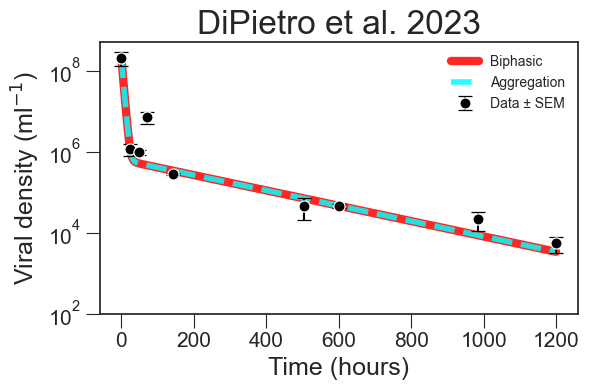


DiPietro et al. 2023
Biphasic parameters:
  p  = 0.997 ± 0.0008124
  k1 = 0.2399 ± 0.1065
  k2 = 0.004359 ± 0.0008346
Aggregation parameters:
  p0 = 0.9996 ± NA
  f  = 2.84e-12 ± NA
  δ  = 0.00218  (mapped)
  d  = 0.2393      (mapped)


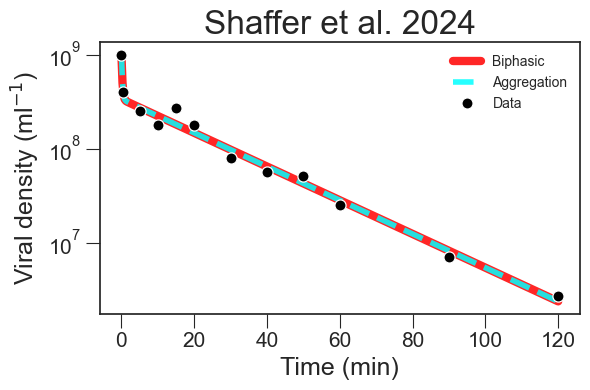


Shaffer et al. 2024
Biphasic parameters:
  p  = 0.6635 ± 0.03532
  k1 = 4.574 ± 2.614
  k2 = 0.04129 ± 0.001859
Aggregation parameters:
  p0 = 0.6696 ± NA
  f  = 1.634e-13 ± NA
  d  = 4.574 ± NA
  δ  = 0.04129  (mapped)


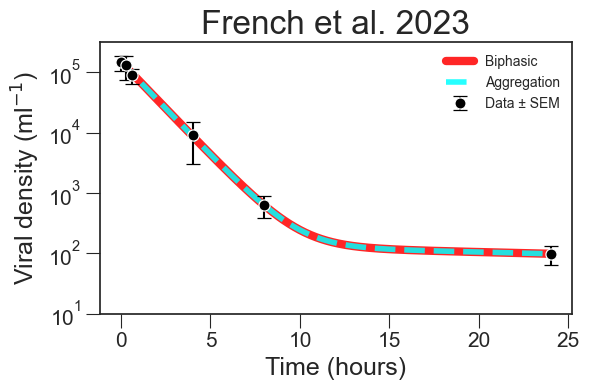


French et al. 2023
Biphasic parameters:
  p  = 0.999 ± 0.001629
  k1 = 0.712 ± 0.03253
  k2 = 0.01625 ± 0.06969
Aggregation parameters:
  p0 = 1 ± 0.01639
  f  = 8.778e-09 ± 4.777e-07
  d  = 0.7116 ± 0.02471
  δ  = 0.01625  (mapped)


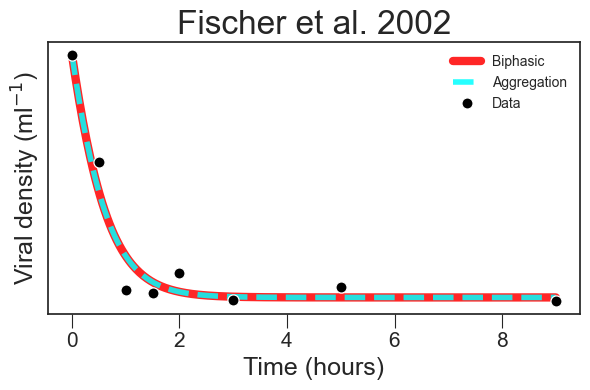


Fischer et al. 2002
Biphasic parameters:
  p  = 0.4763 ± 0.03388
  k1 = 2.053 ± 0.5249
  k2 = 3.891e-09 ± 0.01178
Aggregation parameters:
  p0 = 0.4763 ± NA
  f  = 5.773e-15 ± NA
  d  = 2.053 ± NA
  δ  = 3.891e-09  (mapped)


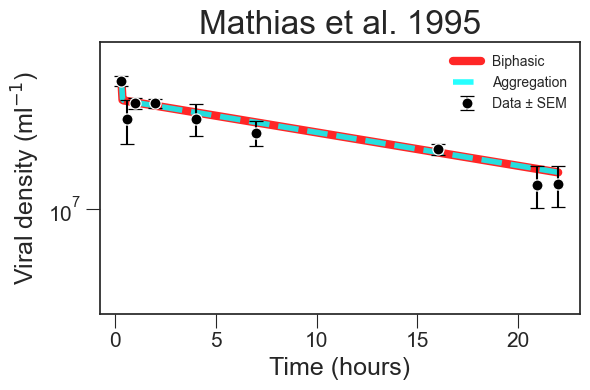


Mathias et al. 1995
Biphasic parameters:
  p  = 0.1918 ± 0.02444
  k1 = 73.56 ± 6.55e+08
  k2 = 0.03674 ± 0.003205
Aggregation parameters:
  p0 = 0.3461 ± 3.769
  f  = 2.728e-06 ± 1.655e-05
  δ  = 0.01837  (mapped)
  d  = 40.85      (mapped)


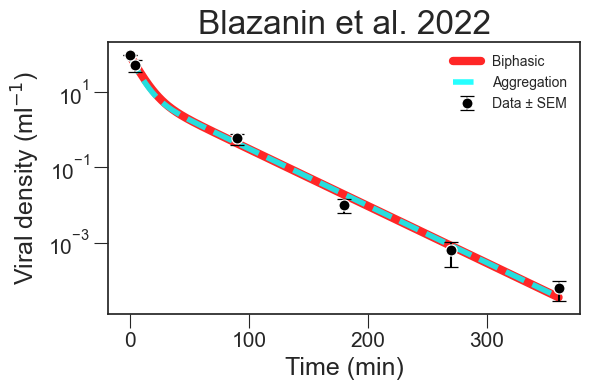


Blazanin et al. 2022
Biphasic parameters:
  p  = 0.8975 ± 0.05685
  k1 = 0.1384 ± 0.1025
  k2 = 0.03495 ± 0.002734
Aggregation parameters:
  p0 = 1 ± 0.2839
  f  = 0.000181 ± 0.0008567
  d  = 0.1435 ± 0.002732
  δ  = 0.03495  (mapped)


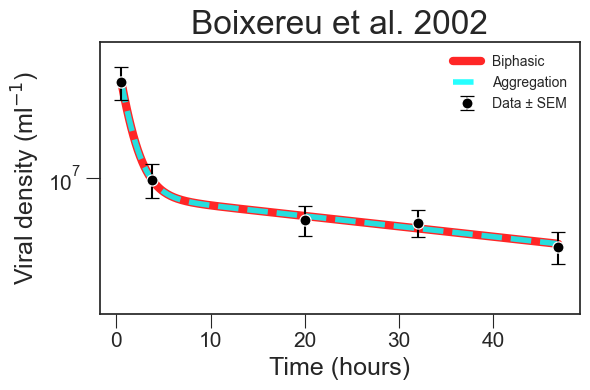


Boixereu et al. 2002
Biphasic parameters:
  p  = 0.6189 ± 0.03283
  k1 = 0.6883 ± 0.1583
  k2 = 0.008774 ± 0.002555
Aggregation parameters:
  p0 = 0.6238 ± NA
  f  = 7.075e-12 ± NA
  δ  = 0.004387  (mapped)
  d  = 0.6882      (mapped)


In [37]:
# Fit and plot each dataset individually
np.seterr(divide="ignore", invalid="ignore")
AGG_PANELS.clear()

for dataset in DATASETS:
    t = dataset["t"]
    y = dataset["y"]
    sem = dataset.get("sem")

    # Fischer et al. 2002 has replicate measurements at shared time points; collapse to means.
    if dataset.get("collapse_replicates", False):
        t, y, sem = collapse_replicates(t, y, sem=None)

    fit_and_plot_dataset(title=dataset["title"], t=t, y=y, sem=sem, mode=dataset["mode"], xlabel=dataset["xlabel"], ylim=dataset.get("ylim"),)

# Figure 4: Aggregation vs biphasic combined figure: (a) DiPietro et al. 2023; (b) Shaffer et al. 2024; (c) French et al. 2023; (d) Fischer et al. 2002; (e) Mathias et al. 1995; (f) Blazanin et al. 2022, (g) "Boixereu et al. 2002"

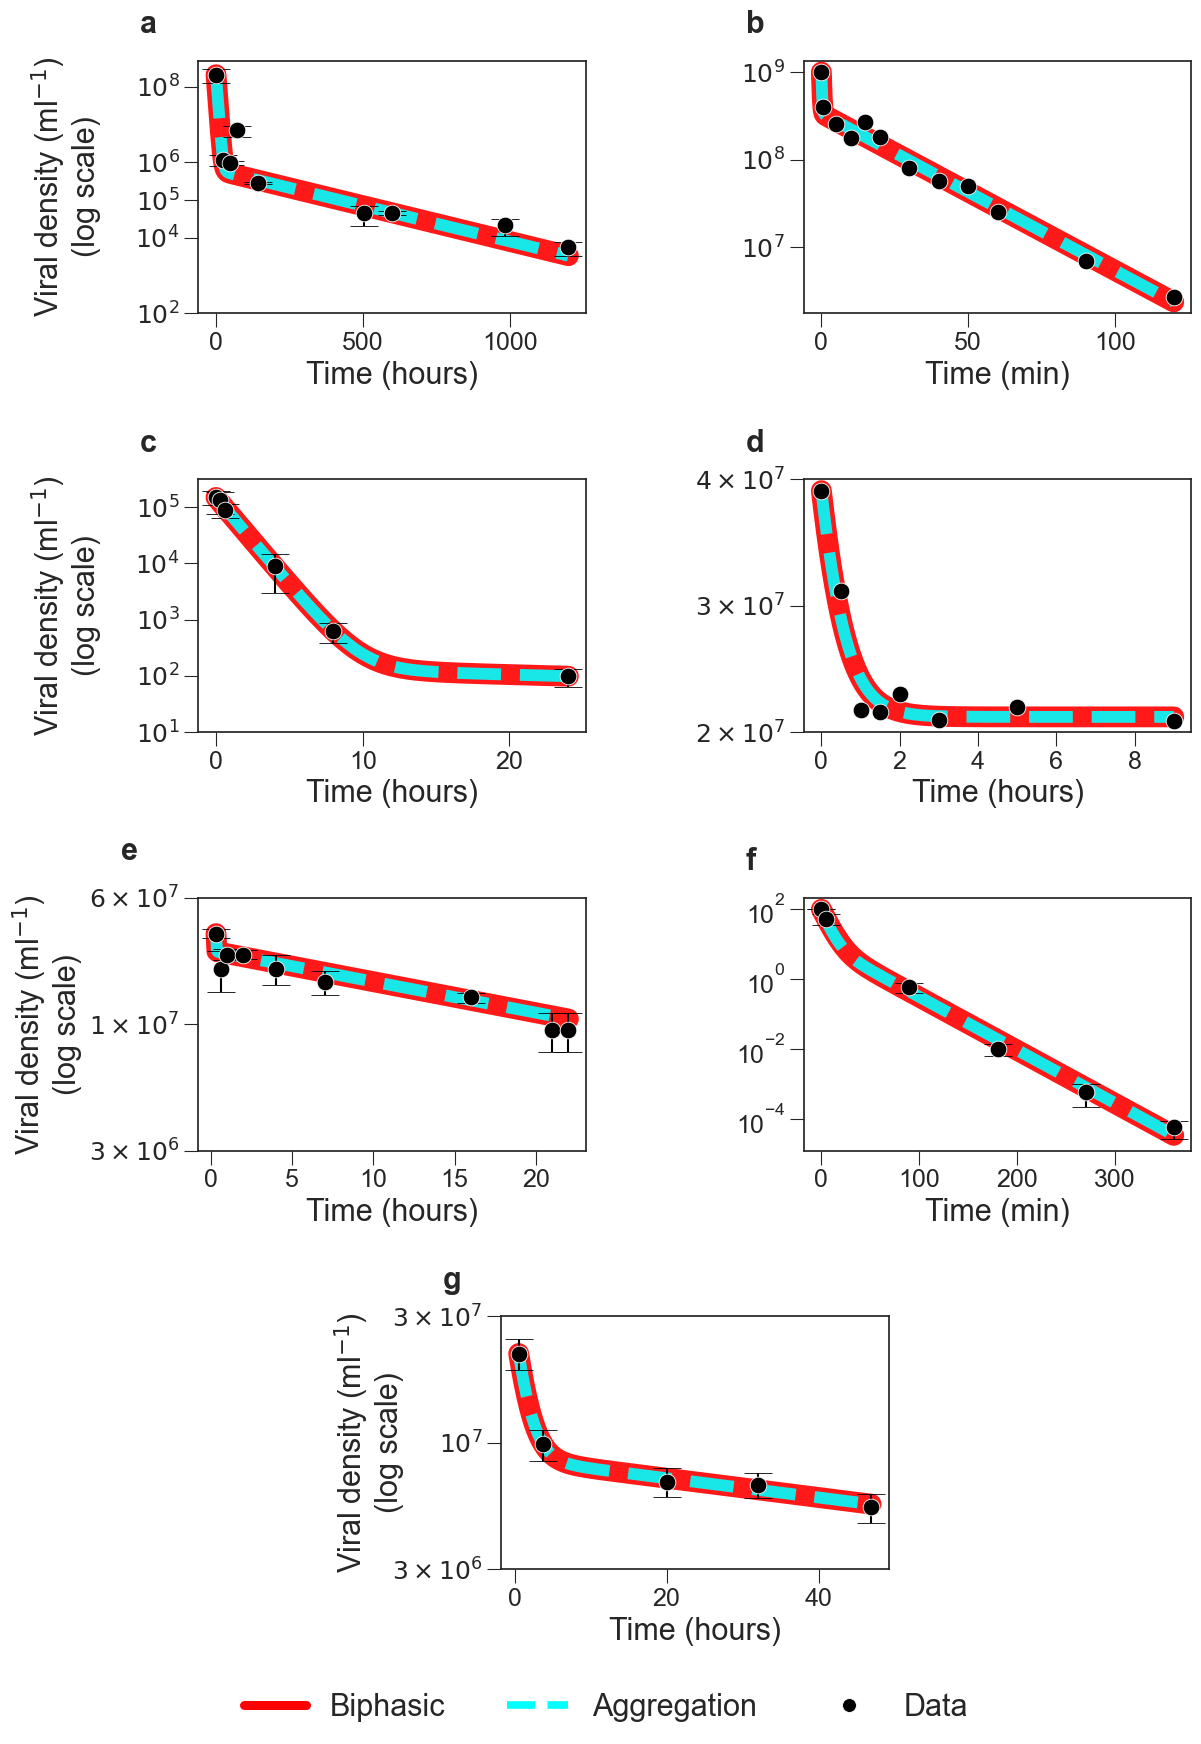

In [38]:
# Combined aggregation figure


# Panel order
panel_order = [
    "DiPietro et al. 2023",
    "Shaffer et al. 2024",
    "French et al. 2023",
    "Fischer et al. 2002",
    "Mathias et al. 1995",
    "Blazanin et al. 2022",
    "Boixereu et al. 2002",
]

# Validate panels
panels = {p["title"]: p for p in AGG_PANELS}
missing = [title for title in panel_order if title not in panels]
if missing:
    raise ValueError("Run the individual dataset fitting cell first. Missing: " + ", ".join(missing))

# Helper function
def set_minimum_log_yticks(ax, min_ticks=3, max_ticks=5):
    """
    Ensure each log-scale y-axis has at least min_ticks labeled major ticks,
    while removing minor ticks.
    """
    ymin, ymax = ax.get_ylim()
    if ymin <= 0 or ymax <= 0:
        return

    lo_exp = np.floor(np.log10(ymin))
    hi_exp = np.ceil(np.log10(ymax))
    decade_ticks = 10.0 ** np.arange(lo_exp, hi_exp + 1)
    decade_ticks = decade_ticks[(decade_ticks >= ymin) & (decade_ticks <= ymax)]

    if len(decade_ticks) >= min_ticks:
        ticks = decade_ticks
        if len(ticks) > max_ticks:
            idx = np.linspace(0, len(ticks) - 1, max_ticks).round().astype(int)
            ticks = ticks[idx]
    else:
        ticks = np.geomspace(ymin, ymax, min_ticks)

    def log_tick_formatter(val, pos):
        if val <= 0:
            return ""
        exp = np.log10(val)
        if np.isclose(exp, round(exp), atol=1e-8):
            return rf"$10^{{{int(round(exp))}}}$"
        base_exp = int(np.floor(exp))
        mantissa = val / (10 ** base_exp)
        return rf"${mantissa:.1g}\times10^{{{base_exp}}}$"

    ax.yaxis.set_major_locator(mticker.FixedLocator(ticks))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# Plot setup
fig = plt.figure(figsize=(12, 18))
gs = fig.add_gridspec(4, 4)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[1, 0:2]),
    fig.add_subplot(gs[1, 2:4]),
    fig.add_subplot(gs[2, 0:2]),
    fig.add_subplot(gs[2, 2:4]),
    fig.add_subplot(gs[3, 1:3]),
]

panel_labels = list(string.ascii_lowercase)

# Plot each panel
for i, (ax, title) in enumerate(zip(axes, panel_order)):
    p = panels[title]

    ax.errorbar(
        p["x"], p["y"], yerr=p["yerr"], fmt="o", capsize=10, markersize=12,
        color="black", markeredgecolor="white", markeredgewidth=0.6, zorder=5,
    )
    ax.plot(p["t_fit"], p["bi_fit"], color="red", linewidth=15, alpha=0.9)
    ax.plot(p["t_fit"], p["agg_fit"], color="cyan", linestyle="--", linewidth=8.5, alpha=0.9)
    ax.set_yscale("log")

    if p.get("ylim") is not None:
        ax.set_ylim(*p["ylim"])

    set_minimum_log_yticks(ax, min_ticks=3, max_ticks=5)

    # Remove the 10^-1 tick on panel f (Blazanin)
    if title == "Blazanin et al. 2022":
        f_ticks = [1e2, 1e0, 1e-2, 1e-4]
        ax.yaxis.set_major_locator(mticker.FixedLocator(f_ticks))
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_locator(mticker.NullLocator())
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    ax.set_xlabel(p["xlabel"], fontsize=22)

    # Give panel e a bit more breathing room
    label_x = -0.20 if title == "Mathias et al. 1995" else -0.15
    label_y = 1.24 if title == "Mathias et al. 1995" else 1.20

    ax.text(
        label_x, label_y, f"{panel_labels[i]}",
        transform=ax.transAxes, fontsize=22, fontweight="bold",
        va="top", ha="left", clip_on=False,
    )

    if i % 2 == 0:
        ax.set_ylabel("Viral density (ml$^{-1}$)\n(log scale)", fontsize=22)
        if title == "Mathias et al. 1995":
            ax.yaxis.set_label_coords(-0.30, 0.5)
        else:
            ax.yaxis.set_label_coords(-0.25, 0.5)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.tick_params(axis="both", which="minor", labelsize=18)

# Shared legend
legend_handles = [
    Line2D([0], [0], color="red", linewidth=6.5, label="Biphasic"),
    Line2D([0], [0], color="cyan", linestyle="--", linewidth=5.5, label="Aggregation"),
    Line2D([0], [0], marker="o", linestyle="None", markersize=10, color="black",
           markeredgecolor="white", markeredgewidth=0.6, label="Data"),
]

fig.legend(
    handles=legend_handles,
    labels=["Biphasic", "Aggregation", "Data"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    fontsize=22,
    frameon=False,
)

# Save/show
fig.tight_layout(rect=(0.05, 0.08, 1.0, 1.0))
fig.subplots_adjust(left=0.16, bottom=0.12)
plt.savefig("Combined_Aggregation_Panels.pdf", bbox_inches="tight")

plt.show()

# Profile likelihood plots to show parameter unidenfiability : Figure S2 (can potentially take several minutes to run)

## Mathias et al. RSS surfaces (S2a)

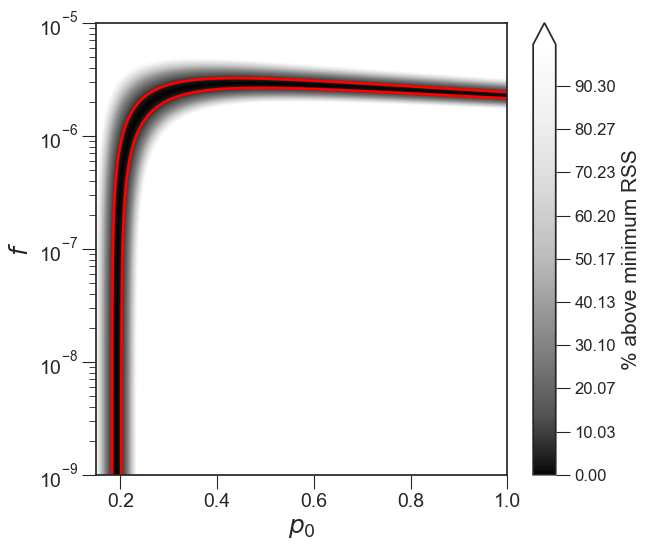

p0 = 0.346105
f  = 2.72839e-06
d  = 40.855
δ  = 0.0183688
minimum RSS = 3.05977


In [39]:



from matplotlib.colors import PowerNorm


# Pull stored Mathias fit
mathias = next(p for p in AGG_PANELS if p["title"] == "Mathias et al. 1995")

t = np.asarray(mathias["x"], dtype=float)
y = np.asarray(mathias["y"], dtype=float)
sem = None if mathias["yerr"] is None else np.asarray(mathias["yerr"], dtype=float)
out = mathias["out"]

V0, p_bi, k1_bi, k2_bi = out["bi_params"]
V0, f_hat, delta_hat, d_hat, p0_hat = out["agg_params"]

tau = t - out["t0"]
logy = np.log10(y)
weights = out["weights"]

S_bi = p_bi * k1_bi + (1.0 - p_bi) * k2_bi


# RSS function for density mode
def rss_density(p0_val, f_val):
    p0_val = float(np.clip(p0_val, 1e-12, 1.0))
    f_val = float(max(f_val, 0.0))
    d_val = S_bi / p0_val

    pred = agg_linear(tau, V0, f_val, delta_hat, d_val, p0_val, mode="density")
    pred = np.clip(np.asarray(pred, dtype=float), 1e-12, np.inf)

    residual = logy - np.log10(pred)
    if weights is not None:
        residual = residual * weights

    return np.sum(residual**2)


# Best-fit RSS
RSS_best = rss_density(p0_hat, f_hat)

def pct_above_minimum(RSS):
    return 100.0 * (RSS - RSS_best) / RSS_best


# Plotting function
def draw_rss_surface(X, Y, Z, xlabel, ylabel, xlog=False, ylog=False, xlim=None, ylim=None, filename=None):
    zmax = 100.0
    Z = np.maximum(Z, 0.0)

    fig, ax = plt.subplots(figsize=(6.6, 5.6))

    cf = ax.contourf(X, Y, Z, levels=np.linspace(0, zmax, 300), cmap="Greys_r", norm=PowerNorm(gamma=0.7, vmin=0, vmax=zmax), extend="max")

    if np.nanmin(Z) <= 5 <= np.nanmax(Z):
        ax.contour(X, Y, Z, levels=[5], colors="red", linewidths=2)

    if xlog:
        ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=14)

    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r"% above minimum RSS", fontsize=15)
    cbar.ax.tick_params(labelsize=12)

    fig.tight_layout()

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")
        fig.savefig(filename.replace(".svg", ".png"), dpi=300, bbox_inches="tight")

    plt.show()


# Grid ranges
p0_lo, p0_hi = 0.15, 1.0
f_lo, f_hi = 1e-9, 1e-5

p0_vals = np.linspace(p0_lo, p0_hi, 320)
f_vals = np.logspace(np.log10(f_lo), np.log10(f_hi), 360)


# p0 vs f surface
P0, F = np.meshgrid(p0_vals, f_vals)
RSS = np.empty_like(P0)

for i in range(F.shape[0]):
    for j in range(F.shape[1]):
        RSS[i, j] = rss_density(P0[i, j], F[i, j])

draw_rss_surface( P0, F, pct_above_minimum(RSS), xlabel=r"$p_0$", ylabel=r"$f$", ylog=True, xlim=(p0_lo, p0_hi), ylim=(f_lo, f_hi), filename="Mathias_p0_vs_f_RSS.svg")


# Parameter check
print(f"p0 = {p0_hat:.6g}")
print(f"f  = {f_hat:.6g}")
print(f"d  = {d_hat:.6g}")
print(f"δ  = {delta_hat:.6g}")
print(f"minimum RSS = {RSS_best:.6g}")

## Shaffer et al.  RSS surfaces (S2b)

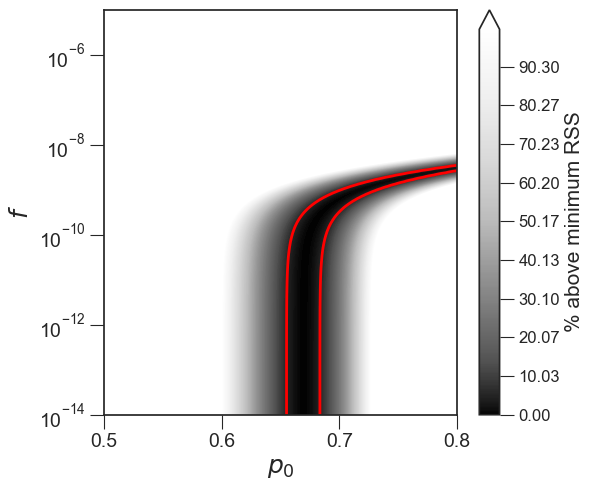

In [ ]:
# Pull stored Shaffer fit
shaffer = next(p for p in AGG_PANELS if p["title"] == "Shaffer et al. 2024")

t = np.asarray(shaffer["x"], dtype=float)
y = np.asarray(shaffer["y"], dtype=float)
out = shaffer["out"]

V0, p, k1, k2 = out["bi_params"]
V0, f_hat, delta_hat, d_hat, p0_hat = out["agg_params"]

tau = t - out["t0"]
lny10 = np.log10(y)
weights = out["weights"]


# RSS function for PFU mode
def rss_pfu(p0_val, f_val, d_val):
    pred = agg_linear(tau, V0, f_val, delta_hat, d_val, p0_val, mode="PFU")
    pred = np.clip(np.asarray(pred, dtype=float), 1e-12, np.inf)
    residual = lny10 - np.log10(pred)

    if weights is not None:
        residual = residual * weights

    return np.sum(residual**2)


# Best-fit RSS
RSS_best = rss_pfu(p0_hat, f_hat, d_hat)

def pct_above_minimum(RSS):
    return 100.0 * (RSS - RSS_best) / RSS_best


# Plotting function
def draw_rss_surface(X, Y, Z, xlabel, ylabel, xlog=False, ylog=False, filename=None):
    zmax = 100.0
    Z = np.maximum(Z, 0.0)

    fig, ax = plt.subplots(figsize=(6, 5))

    cf = ax.contourf(X, Y, Z, levels=np.linspace(0, zmax, 300), cmap="Greys_r", norm=PowerNorm(gamma=0.7, vmin=0, vmax=zmax), extend="max")

    if np.nanmin(Z) <= 5 <= np.nanmax(Z):
        ax.contour(X, Y, Z, levels=[5], colors="red", linewidths=2)

    if xlog:
        ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")

    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=14)

    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r"% above minimum RSS", fontsize=15)
    cbar.ax.tick_params(labelsize=12)

    fig.tight_layout()

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")
        fig.savefig(filename.replace(".svg", ".png"), dpi=300, bbox_inches="tight")

    plt.show()


# Grid ranges
p0_vals = np.linspace(0.5, 0.8, 160)
f_vals = np.logspace(-14, -5, 180)
d_vals = np.linspace(0.0, 10.0, 180)


# p0 vs f, with d fixed
P0, F = np.meshgrid(p0_vals, f_vals)
RSS = np.empty_like(P0)

for i in range(P0.shape[0]):
    for j in range(P0.shape[1]):
        RSS[i, j] = rss_pfu(P0[i, j], F[i, j], d_hat)

draw_rss_surface(P0, F, pct_above_minimum(RSS), xlabel=r"$p_0$", ylabel=r"$f$", ylog=True, filename="Shaffer_p0_vs_f_RSS.svg")


# p0 vs d, with f fixed
P0, D = np.meshgrid(p0_vals, d_vals)
RSS = np.empty_like(P0)

for i in range(P0.shape[0]):
    for j in range(P0.shape[1]):
        RSS[i, j] = rss_pfu(P0[i, j], f_hat, D[i, j])

draw_rss_surface(P0, D, pct_above_minimum(RSS), xlabel=r"$p_0$", ylabel=r"$d$", filename="Shaffer_p0_vs_d_RSS.svg")


# f vs d, with p0 fixed
F, D = np.meshgrid(f_vals, d_vals)
RSS = np.empty_like(F)

for i in range(F.shape[0]):
    for j in range(F.shape[1]):
        RSS[i, j] = rss_pfu(p0_hat, F[i, j], D[i, j])

draw_rss_surface(F, D, pct_above_minimum(RSS), xlabel=r"$f$", ylabel=r"$d$", xlog=True, filename="Shaffer_f_vs_d_RSS.svg")


# Parameter check
print(f"p0 = {p0_hat:.6g}")
print(f"f  = {f_hat:.6g}")
print(f"d  = {d_hat:.6g}")
print(f"δ  = {delta_hat:.6g}")
print(f"minimum RSS = {RSS_best:.6g}")